<a href="https://colab.research.google.com/github/seirah-yang/BootCamp/blob/main/%ED%86%B5%EA%B3%84Tool_Pearson_Spearman_correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. Pearson/Spearman correlation

“Mood stabilizers(기분안정제)”와 “Analgesics(진통제)”의 판매량 상관관계 분석을 통증과 기분장애의 생물학적 연관성 분석

### values
  - mood_sales, pain_sales : QuantitativeContinuous Variables

### mood group vs. pain group
    
    H1 = 진통제 판매량이 높은 지역일수록 Mood stabilizer 판매량도 높을 것이다.
    -> Spearman p 값이 크고 유의미하다면, 지역별 기분안정제 판매 순위가 진통제 판매 순위와 일치하는 경향이 강함

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
df.head()
#'['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel',
 #'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep',
 #'Manager', 'Sales Team']

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [ ]:
df.loc[df["Product Class"] == "Mood Stabilizers", "Product Name"], (df.loc[df["Product Class"] == "Analgesics", "Product Name"])

(0                   Topipizole
 5                    Pazofenac
 7         Morphizolid Tianalin
 8                      Lovapur
 10                Trazobalamin
                   ...         
 254052              Topipizole
 254060              Adriacaine
 254079                Adideine
 254080             Feruprazole
 254081             Feruprazole
 Name: Product Name, Length: 46415, dtype: object,
 3           Lioletine Refliruvax
 4         Oxymotroban Fexoformin
 6                      Symbitrim
 9                        Ampysin
 15            Neuropogen Empibax
                    ...          
 254035              Alglutriptan
 254036      Paronium Atracustone
 254042          Dantolac Pazocor
 254062              Topifribrate
 254076                Dasagestin
 Name: Product Name, Length: 44751, dtype: object)

Pearson 상관계수 (r): 0.1904, P-value: 0.0000
Spearman 상관계수 (ρ): 0.5588, P-value: 0.0000
[Pearson] 값: 0.1904, 유의성: 통계적으로 유의미함, 강도: 약함 또는 없음, 방향: 양의 상관관계 (Mood ↑, Pain ↑)
[Spearman] 값: 0.5588, 유의성: 통계적으로 유의미함, 강도: 강함, 방향: 양의 상관관계 (Mood ↑, Pain ↑)


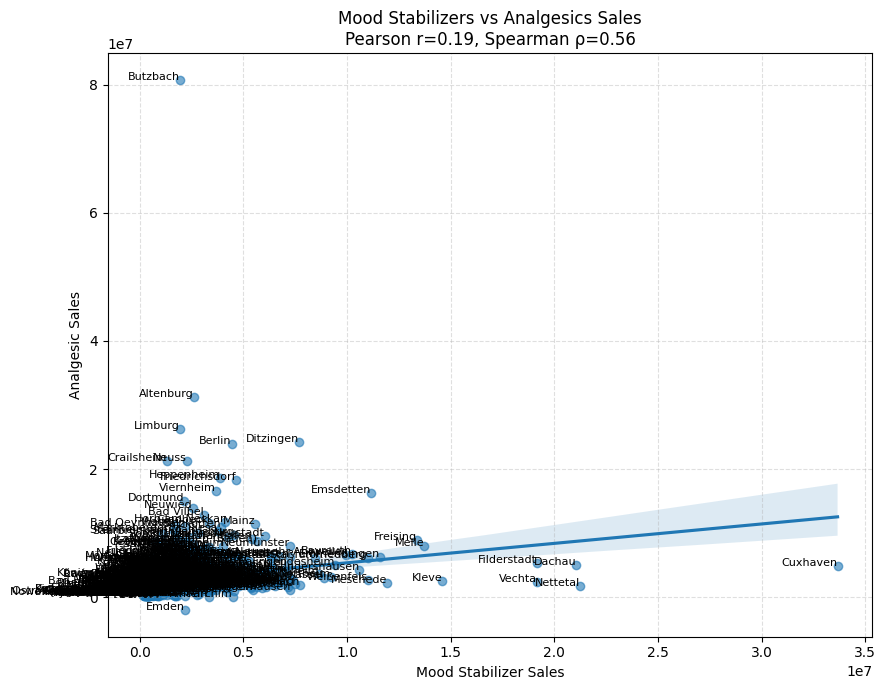

In [ ]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

#1️. 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")

# 2️. 지역별 판매량
mood_group = (df[df["Product Class"] == "Mood Stabilizers"].groupby("City")["Sales"].sum().reset_index(name="mood_sales"))
pain_group = (df[df["Product Class"] == "Analgesics"].groupby("City")["Sales"].sum().reset_index(name="pain_sales"))

merged = pd.merge(mood_group, pain_group, on="City", how="outer")
merged = merged.fillna(0) # 판매량이 없는 지역은 0 으로 간주 (결측치 대체)

# 4️. Pearson, Spearman 상관계수 계산
pearson_corr, pearson_p = pearsonr(merged["mood_sales"], merged["pain_sales"])
spearman_corr, spearman_p = spearmanr(merged["mood_sales"], merged["pain_sales"])

print(f"Pearson 상관계수 (r): {pearson_corr:.4f}, P-value: {pearson_p:.4f}")
print(f"Spearman 상관계수 (ρ): {spearman_corr:.4f}, P-value: {spearman_p:.4f}")

alpha = 0.05

def interpret_correlation(corr, p_value, method):
    abs_corr = abs(corr)
    if abs_corr >= 0.7:
        strength = "매우 강함"
    elif abs_corr >= 0.5:
        strength = "강함"
    elif abs_corr >= 0.3:
        strength = "보통"
    else:
        strength = "약함 또는 없음"

    if p_value < alpha:
        significance = "통계적으로 유의미함"
        if corr > 0:
            direction = "양의 상관관계 (Mood ↑, Pain ↑)"
        elif corr < 0:
            direction = "음의 상관관계 (Mood ↑, Pain ↓)"
        else:
            direction = "상관관계 없음"
    else:
        significance = "통계적으로 유의미하지 않음"
        direction = "상관관계 없음"

    result = (f"[{method}] 값: {corr:.4f}, 유의성: {significance}, "
              f"강도: {strength}, 방향: {direction}")
    return result

print(interpret_correlation(pearson_corr, pearson_p, "Pearson"))
print(interpret_correlation(spearman_corr, spearman_p, "Spearman"))

# 5. 그래프
plt.figure(figsize=(9,7))
sns.regplot(x="mood_sales", y="pain_sales", data=merged, scatter_kws={"alpha":0.6})
plt.title(f"Mood Stabilizers vs Analgesics Sales\n"
          f"Pearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}")
plt.xlabel("Mood Stabilizer Sales")
plt.ylabel("Analgesic Sales")
plt.grid(True, linestyle="--", alpha=0.4)

for i in range(len(merged)):
    plt.text(merged['mood_sales'][i], merged['pain_sales'][i], merged['City'][i],
             fontsize=8, ha='right')

plt.tight_layout()
plt.show()
